In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Cardiovascular_Disease_range_1000_.csv to Cardiovascular_Disease_range_1000_.csv


In [ ]:
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
print("Initial shape:", df.shape)
df.head()

Initial shape: (1000, 13)


,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
0,53,1,2,171,0,0,1,147,0,5.3,3,3,1
1,40,1,0,94,229,0,1,115,0,3.7,1,1,0
2,49,1,2,133,142,0,0,202,1,5.0,1,0,0
3,43,1,0,138,295,1,1,153,0,3.2,2,2,1
4,31,1,1,199,0,0,2,136,0,5.3,3,2,1


In [ ]:
print("Data types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget distribution:\n", df['target'].value_counts())

Data types:
 age                    int64
gender                 int64
chestpain              int64
restingBP              int64
serumcholestrol        int64
fastingbloodsugar      int64
restingrelectro        int64
maxheartrate           int64
exerciseangia          int64
oldpeak              float64
slope                  int64
noofmajorvessels       int64
target                 int64
dtype: object

Missing values per column:
 age                  0
gender               0
chestpain            0
restingBP            0
serumcholestrol      0
fastingbloodsugar    0
restingrelectro      0
maxheartrate         0
exerciseangia        0
oldpeak              0
slope                0
noofmajorvessels     0
target               0
dtype: int64

Duplicate rows: 0

Target distribution:
 target
1    580
0    420
Name: count, dtype: int64


In [ ]:
df = df.drop_duplicates()
df = df.dropna()
print("Shape after cleaning:", df.shape)
print("Duplicate rows remaining:", df.duplicated().sum())
print("Missing values remaining:", df.isnull().sum().sum())

Shape after cleaning: (1000, 13)
Duplicate rows remaining: 0
Missing values remaining: 0


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nTraining target distribution:\n", y_train.value_counts(normalize=True))
print("\nTest target distribution:\n", y_test.value_counts(normalize=True))

Training set shape: (800, 12)
Test set shape: (200, 12)

Training target distribution:
 target
1    0.58
0    0.42
Name: proportion, dtype: float64

Test target distribution:
 target
1    0.58
0    0.42
Name: proportion, dtype: float64


In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Missing values in X_train after imputation:", X_train_imputed.isnull().sum().sum())
print("Missing values in X_test after imputation:", X_test_imputed.isnull().sum().sum())
print("\nX_train_imputed shape:", X_train_imputed.shape)
print("X_test_imputed shape:", X_test_imputed.shape)

Missing values in X_train after imputation: 0
Missing values in X_test after imputation: 0

X_train_imputed shape: (800, 12)
X_test_imputed shape: (200, 12)


In [ ]:
def get_iqr_bounds(train_col):
    Q1 = train_col.quantile(0.25)
    Q3 = train_col.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

numeric_cols = X_train_imputed.columns.tolist()
bounds = {}

for col in numeric_cols:
    lower, upper = get_iqr_bounds(X_train_imputed[col])
    bounds[col] = (lower, upper)
    n_outliers_train = ((X_train_imputed[col] < lower) | (X_train_imputed[col] > upper)).sum()
    print(f"{col}: lower={lower:.2f}, upper={upper:.2f}, outliers_in_train={n_outliers_train}")

age: lower=-11.00, upper=109.00, outliers_in_train=0
gender: lower=1.00, upper=1.00, outliers_in_train=189
chestpain: lower=-3.00, upper=5.00, outliers_in_train=0
restingBP: lower=52.12, upper=257.12, outliers_in_train=0
serumcholestrol: lower=-26.00, upper=662.00, outliers_in_train=0
fastingbloodsugar: lower=-1.50, upper=2.50, outliers_in_train=0
restingrelectro: lower=-1.50, upper=2.50, outliers_in_train=0
maxheartrate: lower=40.00, upper=256.00, outliers_in_train=0
exerciseangia: lower=-1.50, upper=2.50, outliers_in_train=0
oldpeak: lower=-2.96, upper=8.34, outliers_in_train=0
slope: lower=-0.50, upper=3.50, outliers_in_train=0
noofmajorvessels: lower=-3.00, upper=5.00, outliers_in_train=0


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imputed),
    columns=X_train_imputed.columns,
    index=X_train_imputed.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imputed),
    columns=X_test_imputed.columns,
    index=X_test_imputed.index
)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (800, 12)
Test shape: (200, 12)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_capped),
    columns=X_train_capped.columns,
    index=X_train_capped.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_capped),
    columns=X_test_capped.columns,
    index=X_test_capped.index
)

print("X_train_scaled stats:\n", X_train_scaled.describe().loc[['mean', 'std']])
print("\nX_test_scaled shape:", X_test_scaled.shape)
X_train_scaled.head()

X_train_scaled stats:
                age        gender     chestpain     restingBP  serumcholestrol  \
mean -1.554312e-16 -1.043610e-16  3.996803e-17 -2.176037e-16    -6.439294e-17   
std   1.000626e+00  1.000626e+00  1.000626e+00  1.000626e+00     1.000626e+00   

      fastingbloodsugar  restingrelectro  maxheartrate  exerciseangia  \
mean       5.329071e-17    -3.330669e-17 -2.642331e-16  -6.328271e-17   
std        1.000626e+00     1.000626e+00  1.000626e+00   1.000626e+00   

           oldpeak         slope  noofmajorvessels  
mean  8.659740e-17 -5.773160e-17     -1.332268e-17  
std   1.000626e+00  1.000626e+00      1.000626e+00  

X_test_scaled shape: (200, 12)


,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels
289,0.154414,0.556174,-1.021562,-0.126198,1.757440,-0.627478,0.327621,-0.301112,1.012579,-1.046235,0.456386,0.790183
821,-0.180208,0.556174,-1.021562,-0.962225,-0.465192,1.593682,-0.976343,-1.488201,-0.987577,-1.568590,-1.527901,-1.255598
66,1.660211,0.556174,2.137908,1.612738,-0.343404,1.593682,1.631586,0.618881,-0.987577,-0.930156,1.448530,0.790183
190,1.269819,0.556174,1.084752,0.943916,1.810723,1.593682,-0.976343,-0.004340,-0.987577,1.449464,0.456386,-0.232708
256,1.660211,0.556174,1.084752,0.709829,-2.352908,-0.627478,-0.976343,-0.657239,-0.987577,1.855741,0.456386,0.790183


In [ ]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_scaled, y_train), 1):
    fold_train_dist = y_train.iloc[train_idx].value_counts(normalize=True).to_dict()
    fold_val_dist = y_train.iloc[val_idx].value_counts(normalize=True).to_dict()
    print(f"Fold {fold}: train_size={len(train_idx)}, val_size={len(val_idx)}, "
          f"val_class_dist={fold_val_dist}")

Fold 1: train_size=640, val_size=160, val_class_dist={1: 0.58125, 0: 0.41875}
Fold 2: train_size=640, val_size=160, val_class_dist={1: 0.58125, 0: 0.41875}
Fold 3: train_size=640, val_size=160, val_class_dist={1: 0.58125, 0: 0.41875}
Fold 4: train_size=640, val_size=160, val_class_dist={1: 0.58125, 0: 0.41875}
Fold 5: train_size=640, val_size=160, val_class_dist={1: 0.575, 0: 0.425}


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42)
}

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

In [ ]:
cv_results = {}

for name, model in models.items():
    scores = cross_validate(model, X_train_scaled, y_train, cv=skf, scoring=scoring)
    cv_results[name] = {
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1-Score": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    }
    print(f"{name} done.")

Logistic Regression done.
Random Forest done.
XGBoost done.
CatBoost done.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

test_results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    test_results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }
    print(f"{name} evaluated.")

Logistic Regression evaluated.
Random Forest evaluated.
XGBoost evaluated.
CatBoost evaluated.


In [ ]:
cv_df = pd.DataFrame(cv_results).T.round(4)
test_df = pd.DataFrame(test_results).T.round(4)

print("Cross-Validation Results (Train)")
display(cv_df)

print("\n Test Set Results")
display(test_df)

Cross-Validation Results (Train)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.9625,0.9698,0.9655,0.9675,0.9907
Random Forest,0.9762,0.9746,0.9849,0.9796,0.9950
XGBoost,0.9712,0.9685,0.9827,0.9753,0.9940
CatBoost,0.9800,0.9829,0.9827,0.9827,0.9944



 Test Set Results


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.985,0.9829,0.9914,0.9871,0.9982
Random Forest,0.985,0.9829,0.9914,0.9871,0.9994
XGBoost,0.990,0.9914,0.9914,0.9914,0.9989
CatBoost,0.990,0.9914,0.9914,0.9914,0.9993


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

overfit_results = {}

for name, model in models.items():

    model.fit(X_train_scaled, y_train)
    y_train_pred = model.predict(X_train_scaled)
    y_train_prob = model.predict_proba(X_train_scaled)[:, 1]
    train_acc = accuracy_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    train_auc = roc_auc_score(y_train, y_train_prob)

    cv_acc = cv_results[name]["Accuracy"]
    cv_f1 = cv_results[name]["F1-Score"]
    cv_auc = cv_results[name]["ROC-AUC"]


    y_test_pred = model.predict(X_test_scaled)
    y_test_prob = model.predict_proba(X_test_scaled)[:, 1]
    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_auc = roc_auc_score(y_test, y_test_prob)

    overfit_results[name] = {
        "Train Acc": train_acc, "CV Acc": cv_acc, "Test Acc": test_acc,
        "Acc Gap (Train-Test)": train_acc - test_acc,
        "Train F1": train_f1, "CV F1": cv_f1, "Test F1": test_f1,
        "F1 Gap (Train-Test)": train_f1 - test_f1,
        "Train AUC": train_auc, "CV AUC": cv_auc, "Test AUC": test_auc,
        "AUC Gap (Train-Test)": train_auc - test_auc
    }

overfit_df = pd.DataFrame(overfit_results).T.round(4)
display(overfit_df)

,Train Acc,CV Acc,Test Acc,Acc Gap (Train-Test),Train F1,CV F1,Test F1,F1 Gap (Train-Test),Train AUC,CV AUC,Test AUC,AUC Gap (Train-Test)
Logistic Regression,0.965,0.9625,0.985,-0.020,0.9698,0.9675,0.9871,-0.0173,0.9932,0.9907,0.9982,-0.0050
Random Forest,1.000,0.9762,0.985,0.015,1.0000,0.9796,0.9871,0.0129,1.0000,0.9950,0.9994,0.0006
XGBoost,1.000,0.9712,0.990,0.010,1.0000,0.9753,0.9914,0.0086,1.0000,0.9940,0.9989,0.0011
CatBoost,1.000,0.9800,0.990,0.010,1.0000,0.9827,0.9914,0.0086,1.0000,0.9944,0.9993,0.0007


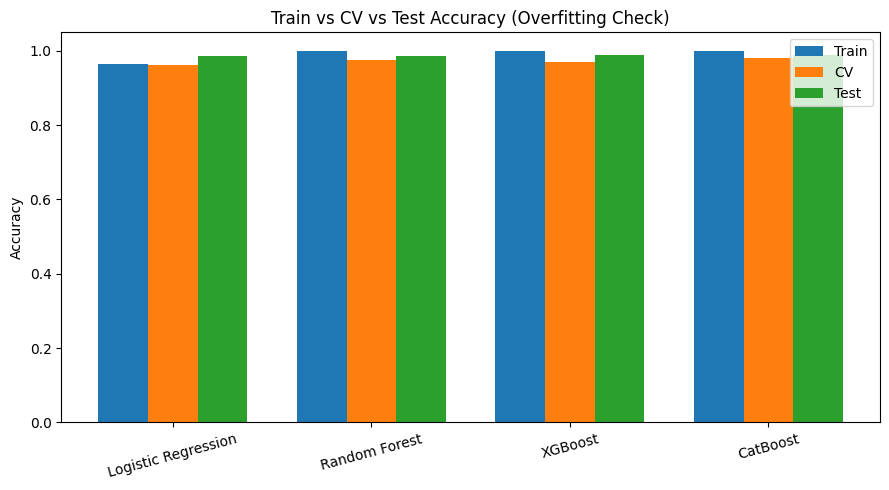

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(9,5))
ax.bar(x - width, overfit_df["Train Acc"], width, label="Train")
ax.bar(x, overfit_df["CV Acc"], width, label="CV")
ax.bar(x + width, overfit_df["Test Acc"], width, label="Test")

ax.set_xticks(x)
ax.set_xticklabels(overfit_df.index, rotation=15)
ax.set_ylabel("Accuracy")
ax.set_title("Train vs CV vs Test Accuracy (Overfitting Check)")
ax.legend()
plt.tight_layout()
plt.show()

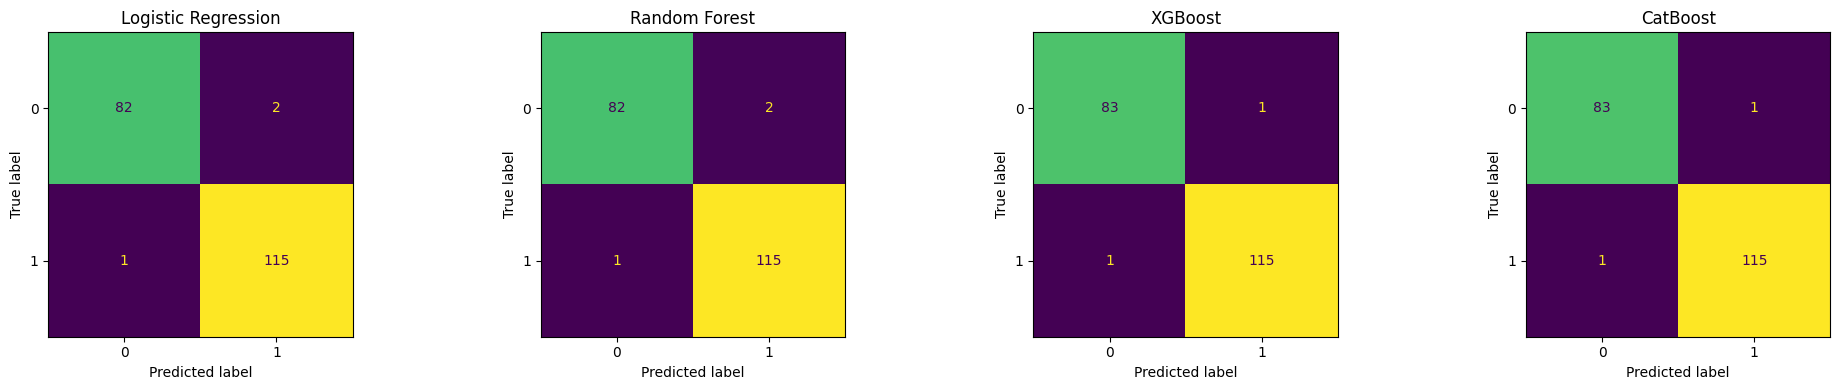

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

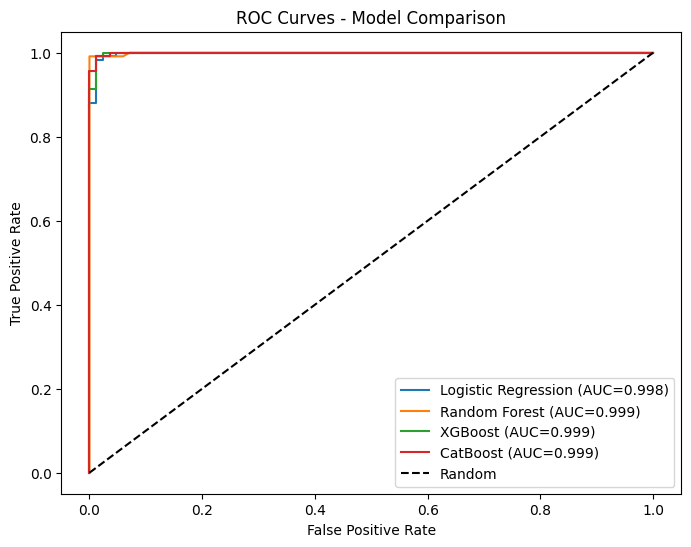

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")
plt.legend()
plt.show()

In [ ]:
!pip install shap

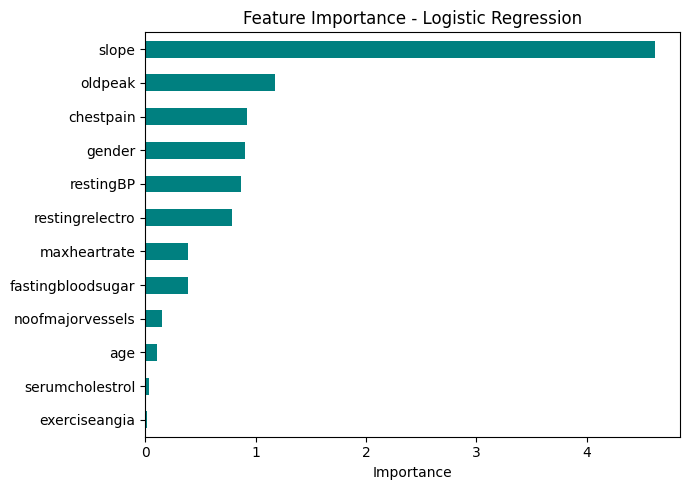

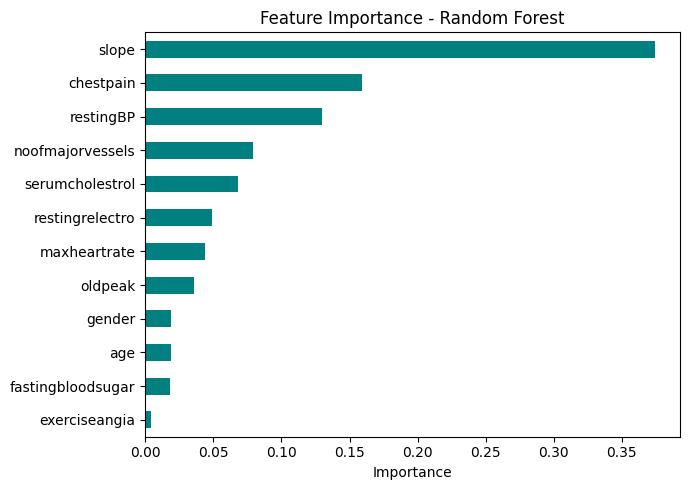

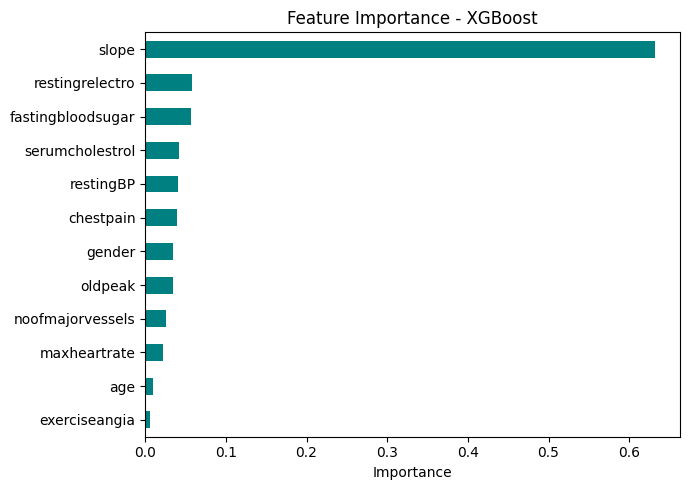

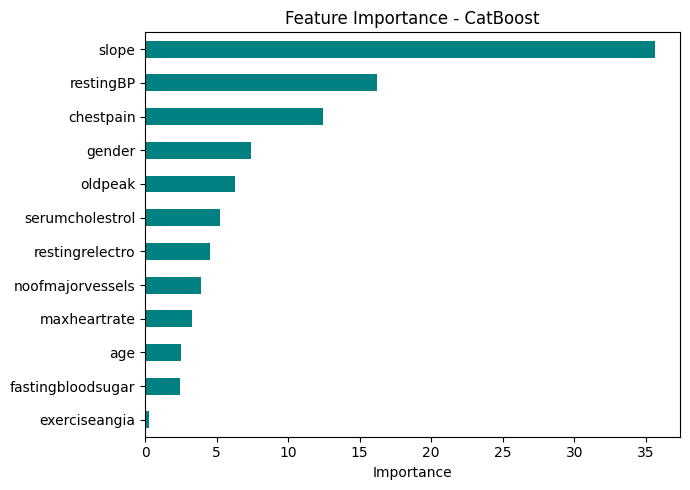

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

feature_names = X_train_scaled.columns

for name, model in models.items():
    plt.figure(figsize=(7, 5))

    if name == "Logistic Regression":
        importance = np.abs(model.coef_[0])
    else:
        importance = model.feature_importances_

    imp_df = pd.Series(importance, index=feature_names).sort_values(ascending=True)
    imp_df.plot(kind="barh", color="teal")
    plt.title(f"Feature Importance - {name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

Computing SHAP for Logistic Regression...


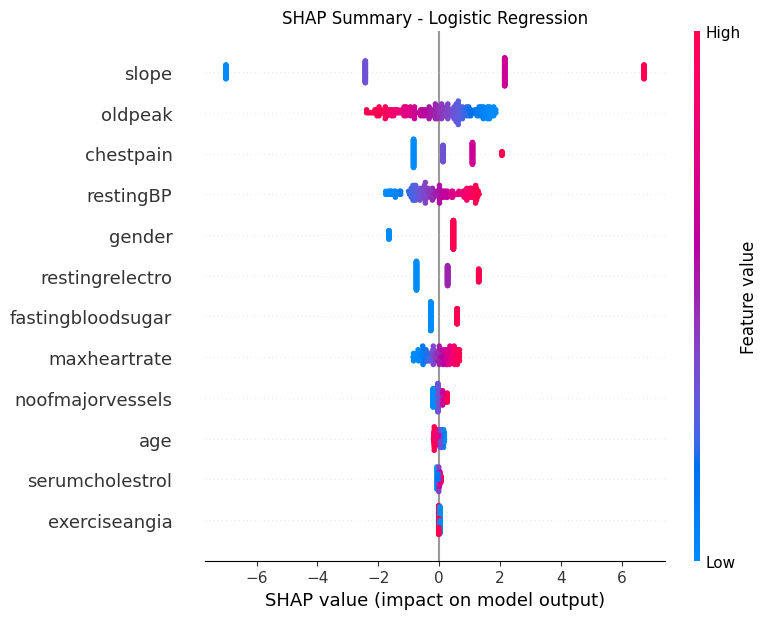

Computing SHAP for Random Forest...


<Figure size 640x480 with 0 Axes>

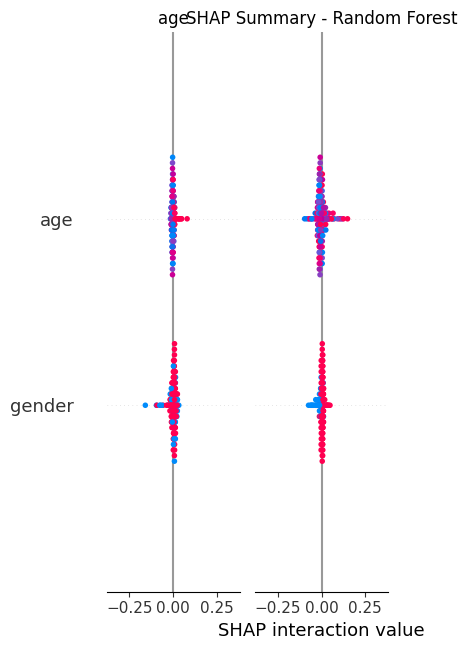

Computing SHAP for XGBoost...


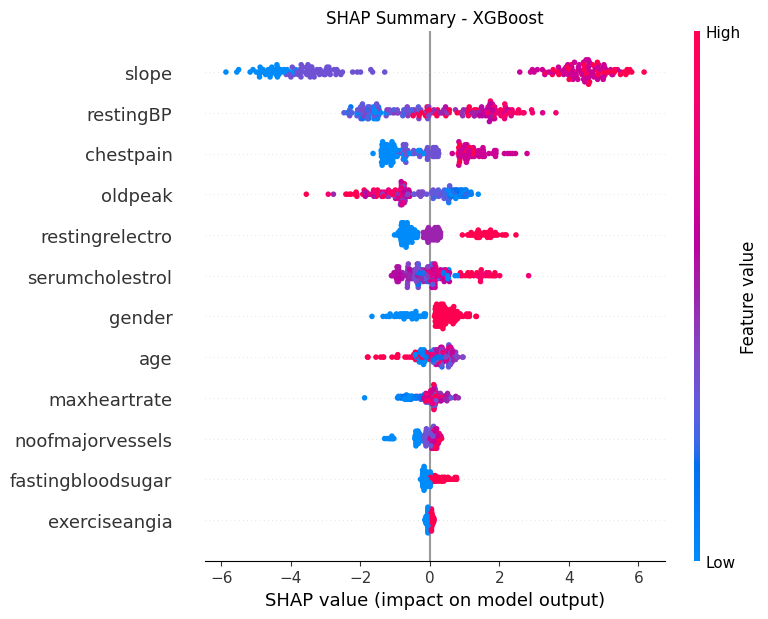

Computing SHAP for CatBoost...


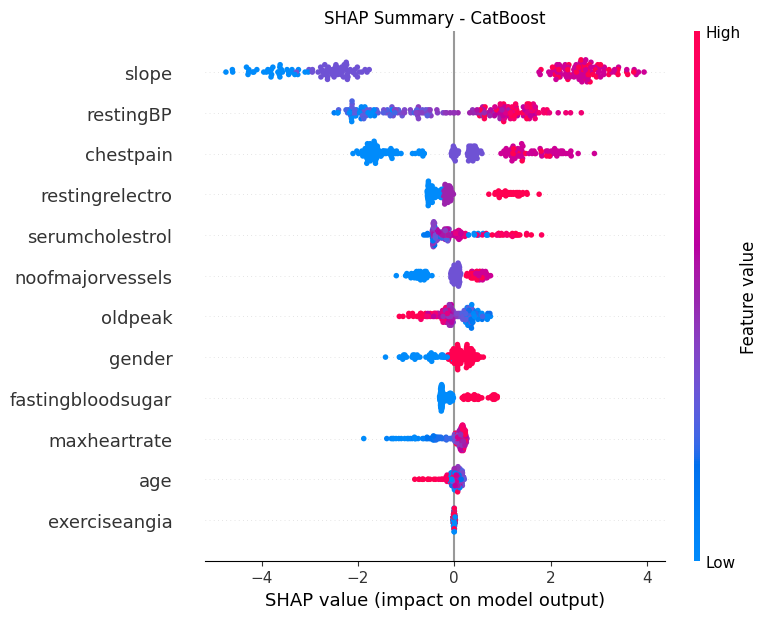

In [ ]:
import shap

shap_values_dict = {}

for name, model in models.items():
    print(f"Computing SHAP for {name}...")

    if name == "Logistic Regression":
        explainer = shap.LinearExplainer(model, X_train_scaled)
        shap_values = explainer.shap_values(X_test_scaled)
    elif name == "Random Forest":
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test_scaled)
        # RF binary classification returns a list [class0, class1]
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
    else:  # XGBoost, CatBoost
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test_scaled)

    shap_values_dict[name] = shap_values

    plt.figure()
    shap.summary_plot(shap_values, X_test_scaled, show=False)
    plt.title(f"SHAP Summary - {name}")
    plt.tight_layout()
    plt.show()